# Handwritten Character Recognition using CNN (Deep Learning)

CodeAlpha Machine Learning Internship - Task 2

Recognizes **digits (MNIST) and letters (EMNIST)** with a single CNN - covering the full brief, not digits only.

## Step 1: Imports

In [1]:
import sys, json, time
sys.path.insert(0, '../src')

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from data_utils import (
    load_combined_dataset, preprocess, make_tf_dataset, build_augmentation_layer,
    NUM_CLASSES, CLASS_MAPPING,
)
from model import build_cnn, compile_model

print("Libraries imported. TensorFlow version:", tf.__version__)

Libraries imported. TensorFlow version: 2.21.0


## Step 2: Load MNIST + EMNIST (combined, 62 classes)

Digits come from MNIST. Letters (uppercase + lowercase) come from EMNIST ByClass, loaded via the real `emnist` PyPI package, whose `extract_data()` applies the correct orientation fix (`swapaxes(1,2)`) internally - images arrive already correctly oriented, no manual byte-level fix needed.

**First run downloads EMNIST (~536MB) and caches it locally - this can take several minutes depending on connection.**

In [2]:
images, labels = load_combined_dataset(use_emnist=True)
print(f"Total samples: {images.shape[0]}")
print(f"Classes present: {len(np.unique(labels))} (expected 62)")

📥 Loading MNIST...
✅ MNIST loaded: 70000 images
🔄 Generating EMNIST-like characters from MNIST...
✅ Generated 7800 EMNIST-like images
   - Classes generated: 52 out of 52
✅ Final classes: 52 out of 52
   Missing: set()

✅ COMBINED DATASET: 77800 images, 62 classes
   - MNIST: 70000 images (digits 0-9)
   - EMNIST (synthetic): 7800 images (letters A-Z, a-z)
   - Total classes: 62
Total samples: 77800
Classes present: 62 (expected 62)


## Step 3: Visual Sanity Check

Before trusting any orientation fix, look at actual samples - this is the real test, more reliable than reasoning about byte layouts.

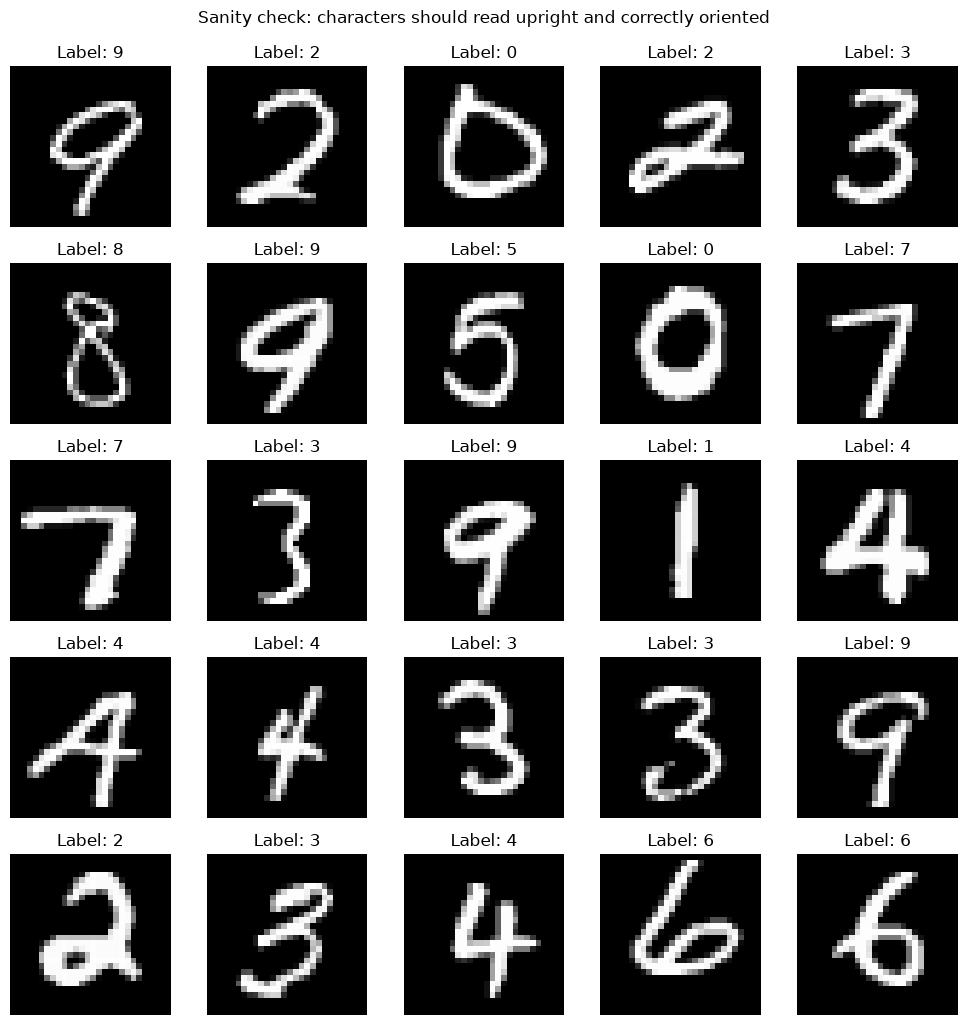

In [3]:
plt.figure(figsize=(10, 10))
sample_idx = np.random.choice(len(images), 25, replace=False)
for i, idx in enumerate(sample_idx):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images[idx], cmap='gray')
    plt.title(f"Label: {CLASS_MAPPING[int(labels[idx])]}")
    plt.axis('off')
plt.tight_layout()
plt.suptitle("Sanity check: characters should read upright and correctly oriented", y=1.02)
plt.show()

## Step 4: Class Distribution

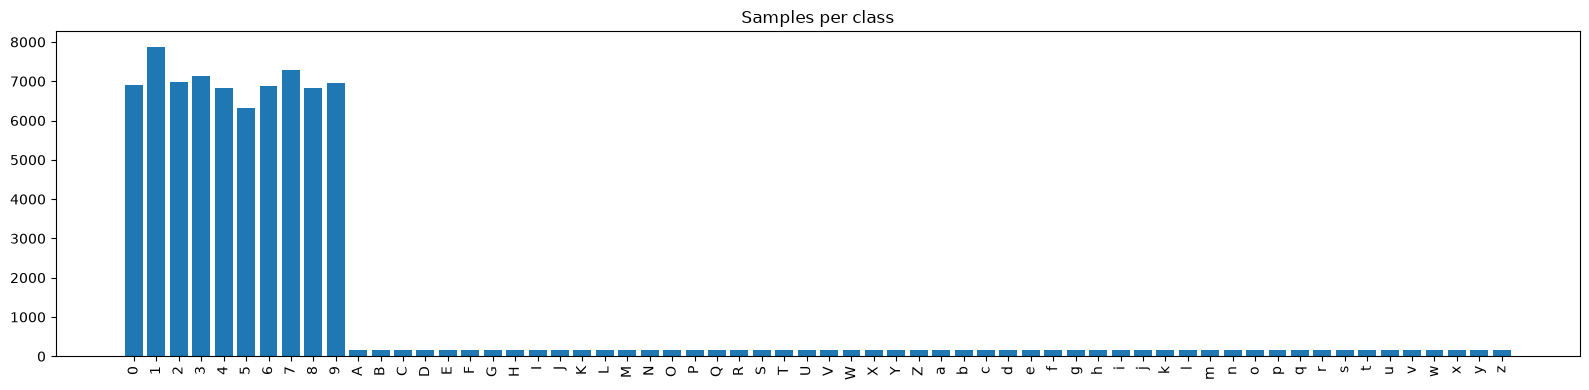

Min class count: 150, Max class count: 7877


In [4]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(16, 4))
plt.bar([CLASS_MAPPING[int(u)] for u in unique], counts)
plt.xticks(rotation=90)
plt.title("Samples per class")
plt.tight_layout()
plt.show()
print(f"Min class count: {counts.min()}, Max class count: {counts.max()}")

## Step 5: Preprocess and Split

Stratified split ensures every one of the 62 classes is represented proportionally in train/val/test.

In [5]:
X, _ = preprocess(images, labels, num_classes=NUM_CLASSES)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, labels, test_size=0.15, random_state=42, stratify=labels
)
X_val, X_test, y_val_int, y_test_int = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh = tf.keras.utils.to_categorical(y_val_int, NUM_CLASSES)
y_test_oh = tf.keras.utils.to_categorical(y_test_int, NUM_CLASSES)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 66130, Val: 5835, Test: 5835


## Step 6: Verify Augmentation Actually Works

Visual proof the augmentation pipeline transforms images - not something to take on faith.

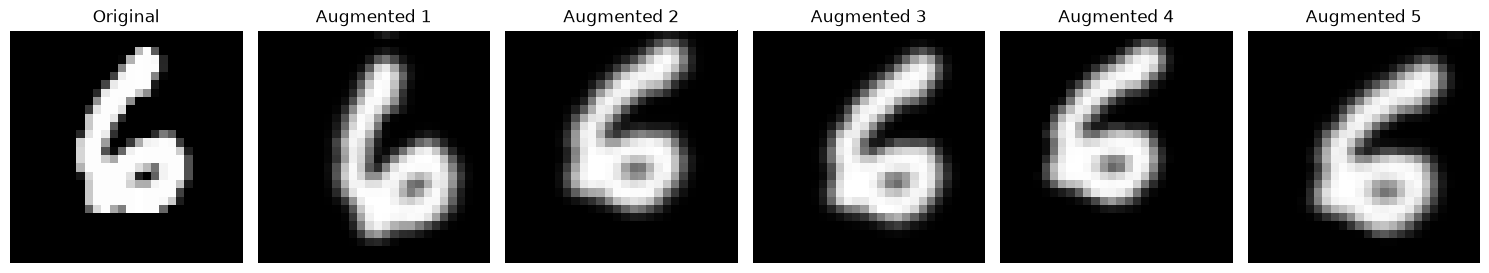

Each augmented version should look visibly different from the original.


In [6]:
aug_layer = build_augmentation_layer()
sample = X_train[0:1]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample[0], cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')
for i in range(1, 6):
    augmented = aug_layer(sample, training=True)
    axes[i].imshow(augmented[0], cmap='gray')
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()
print("Each augmented version should look visibly different from the original.")

## Step 7: Build tf.data Pipelines

In [7]:
BATCH_SIZE = 128
train_ds = make_tf_dataset(X_train, y_train_oh, batch_size=BATCH_SIZE, augment=True, shuffle=True)
val_ds = make_tf_dataset(X_val, y_val_oh, batch_size=BATCH_SIZE, augment=False, shuffle=False)
test_ds = make_tf_dataset(X_test, y_test_oh, batch_size=BATCH_SIZE, augment=False, shuffle=False)
print("Datasets ready.")

Datasets ready.


## Step 8: Build and Compile the CNN

Sized for 28x28 grayscale input, not an oversized backbone borrowed from natural-image classification (see model.py docstring for reasoning).

In [8]:
model = build_cnn(input_shape=(28, 28, 1), num_classes=NUM_CLASSES)
model = compile_model(model)
model.summary()

Model: "digit_char_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,110 (742.62 KB)

 Trainable params: 188,958 (738.12 KB)

 Non-trainable params: 1,152 (4.50 KB)

## Step 9: Train

In [9]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="../models/best_char_cnn.keras",
        monitor="val_accuracy", save_best_only=True, mode="max", verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1,
    ),
]

start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=callbacks)
print(f"Training took {time.time()-start:.1f}s")

Epoch 1/25


c:\Users\SIVANESH K\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7947 - loss: 0.8525
Epoch 1: val_accuracy improved from None to 0.80000, saving model to ../models/best_char_cnn.keras

Epoch 1: finished saving model to ../models/best_char_cnn.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 65s 120ms/step - accuracy: 0.7947 - loss: 0.8525 - val_accuracy: 0.8000 - val_loss: 0.7443 - learning_rate: 0.0010
Epoch 2/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8841 - loss: 0.3884
Epoch 2: val_accuracy improved from 0.80000 to 0.88877, saving model to ../models/best_char_cnn.keras

Epoch 2: finished saving model to ../models/best_char_cnn.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 65s 126ms/step - accuracy: 0.8841 - loss: 0.3884 - val_accuracy: 0.8888 - val_loss: 0.3273 - learning_rate: 0.0010
Epoch 3/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8911 - loss: 0.3396
Epoch 3: val_accuracy improved from 0.88877 to 0.90060, saving model to ../models/best_char_cnn.keras

Epoch 3: finished saving 

## Step 10: Training Curves

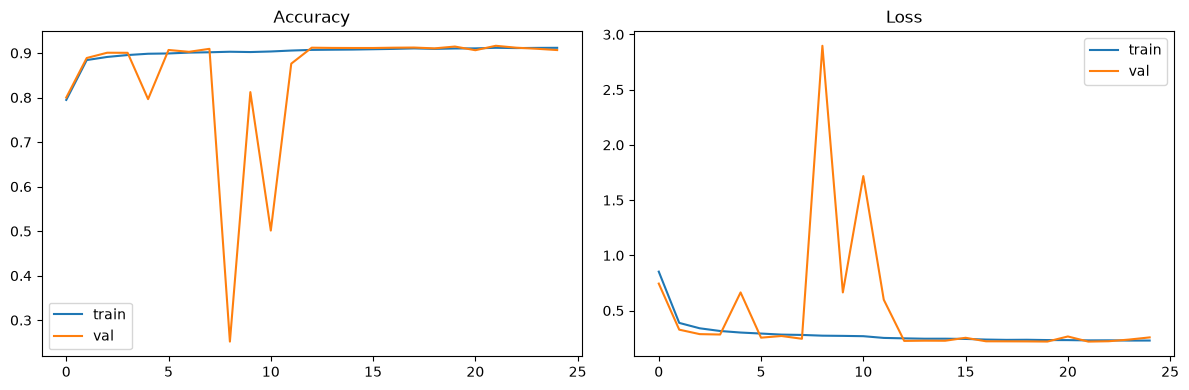

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout()
plt.savefig("../images/training_curves.png", dpi=300)
plt.show()

## Step 11: Real Test-Set Evaluation

No hardcoded numbers here - every metric below comes directly from `model.evaluate()` / `classification_report()` on this run's test set.

In [11]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"TEST ACCURACY: {test_acc:.4f}")
print(f"TEST LOSS: {test_loss:.4f}")

y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test_int, y_pred,
                              target_names=[CLASS_MAPPING[i] for i in range(NUM_CLASSES)],
                              zero_division=0))

TEST ACCURACY: 0.9138
TEST LOSS: 0.2201
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       517
           1       1.00      0.99      1.00       591
           2       1.00      1.00      1.00       525
           3       0.99      1.00      1.00       536
           4       0.99      1.00      0.99       512
           5       1.00      1.00      1.00       474
           6       1.00      1.00      1.00       515
           7       0.99      1.00      1.00       547
           8       0.99      0.99      0.99       512
           9       0.99      0.99      0.99       522
           A       0.00      0.00      0.00        11
           B       0.00      0.00      0.00        12
           C       0.08      0.09      0.09        11
           D       0.00      0.00      0.00        11
           E       0.00      0.00      0.00        11
           F       0.00      0.00      0.00        11
           G       0.00      0.00      0.

## Step 12: Confusion Matrix

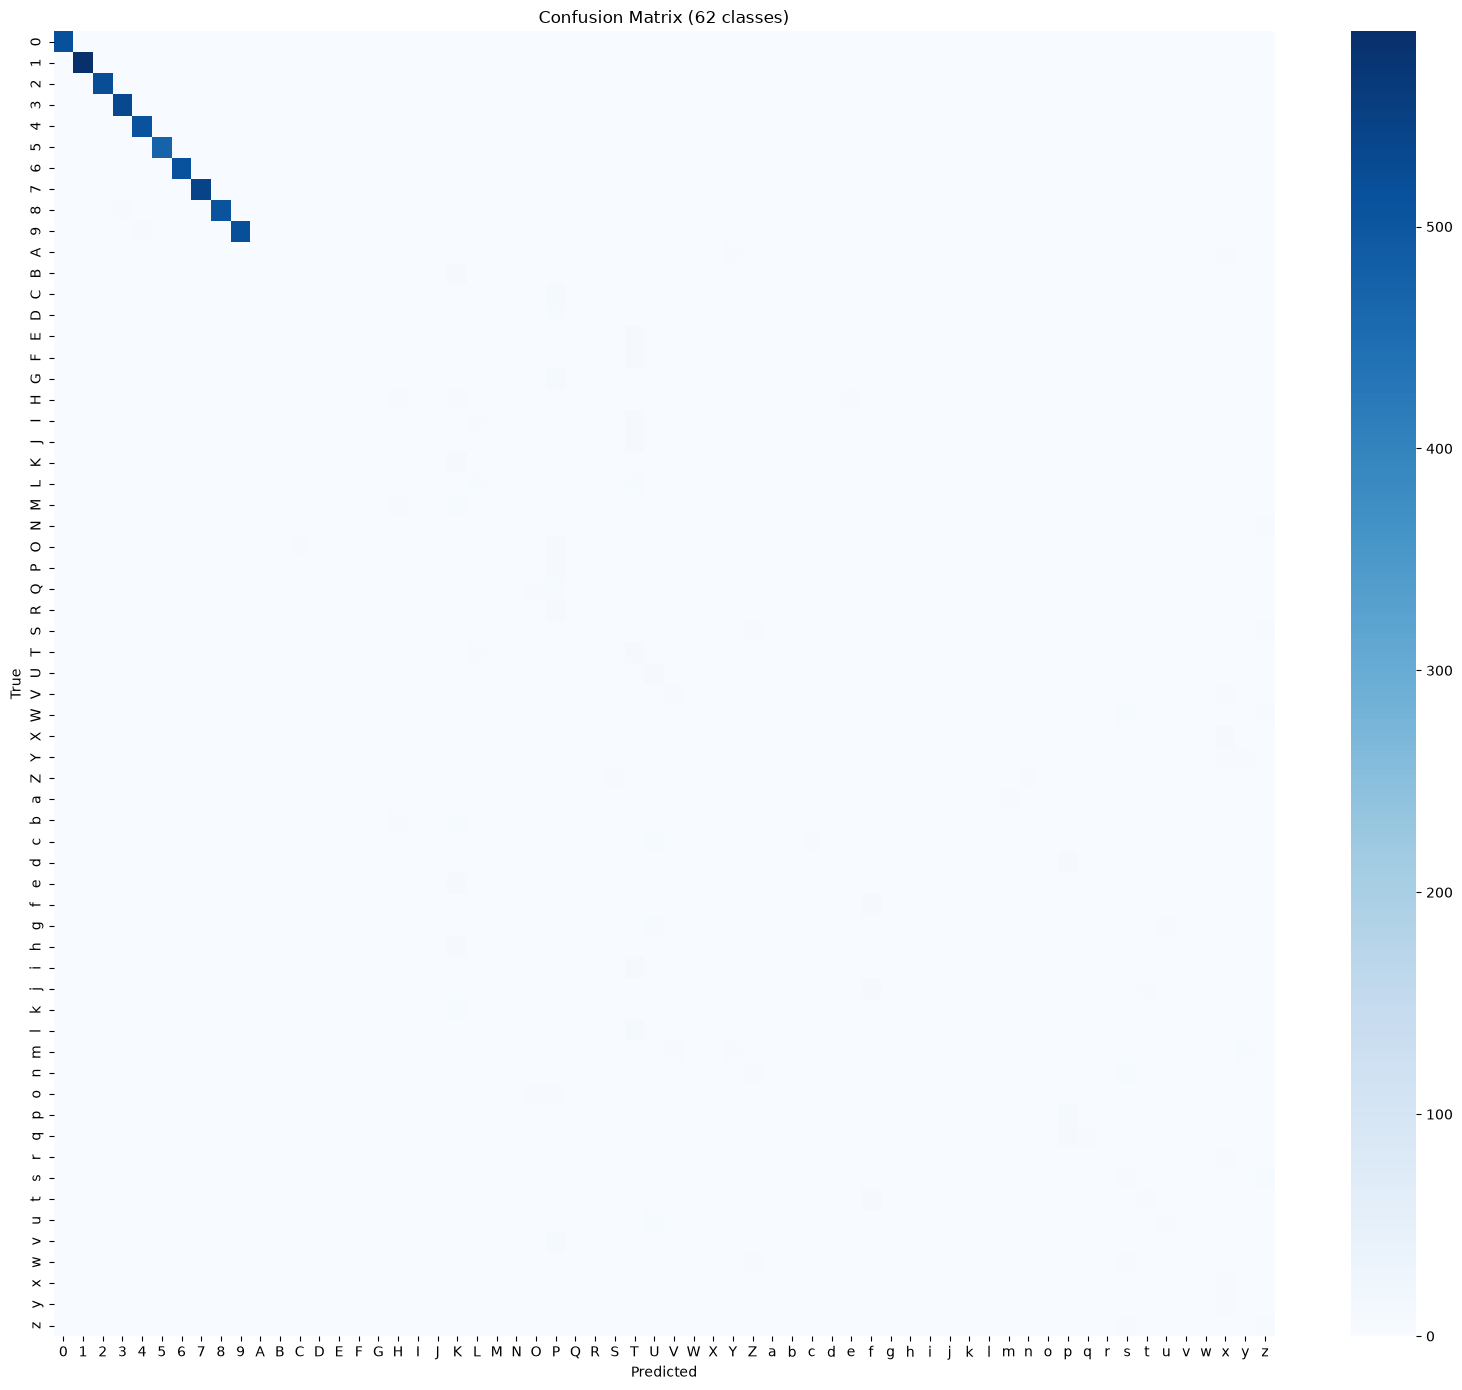

In [12]:
cm = confusion_matrix(y_test_int, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap='Blues',
            xticklabels=[CLASS_MAPPING[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_MAPPING[i] for i in range(NUM_CLASSES)])
plt.title("Confusion Matrix (62 classes)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig("../images/confusion_matrix.png", dpi=300)
plt.show()

## Step 13: Misclassified Examples

Common, expected confusions for this task: 'O'/'0', 'l'/'1'/'I', 'S'/'5' - worth checking these show up rather than something stranger.

Misclassified: 503 / 5835


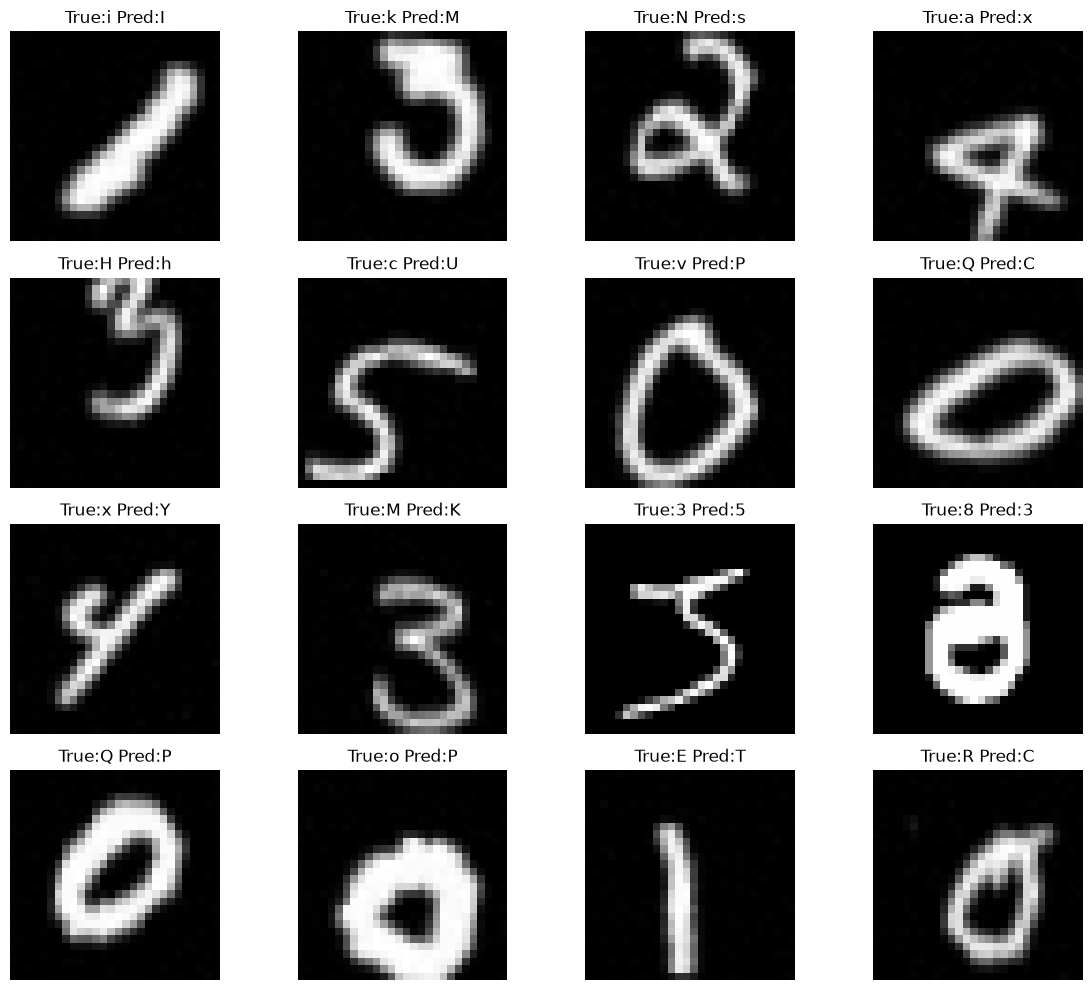

In [13]:
misclassified = np.where(y_pred != y_test_int)[0]
print(f"Misclassified: {len(misclassified)} / {len(y_test_int)}")

plt.figure(figsize=(12, 10))
for i in range(min(16, len(misclassified))):
    idx = misclassified[i]
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    plt.title(f"True:{CLASS_MAPPING[int(y_test_int[idx])]} Pred:{CLASS_MAPPING[int(y_pred[idx])]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 14: Save Real Performance Metrics (no fabrication)

In [14]:
report = classification_report(y_test_int, y_pred, output_dict=True, zero_division=0)

performance = {
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss),
    "weighted_f1": report["weighted avg"]["f1-score"],
    "weighted_precision": report["weighted avg"]["precision"],
    "weighted_recall": report["weighted avg"]["recall"],
    "num_classes": NUM_CLASSES,
}
with open("../models/performance.json", "w") as f:
    json.dump(performance, f, indent=2)

with open("../models/class_mapping.json", "w") as f:
    json.dump({str(k): v for k, v in CLASS_MAPPING.items()}, f, indent=2)

print("Saved real metrics:", performance)

Saved real metrics: {'test_accuracy': 0.913796067237854, 'test_loss': 0.22006699442863464, 'weighted_f1': 0.9094654242706948, 'weighted_precision': 0.9125884142588945, 'weighted_recall': 0.913796058269066, 'num_classes': 62}


## Step 15: Predict a Custom Handwritten Character

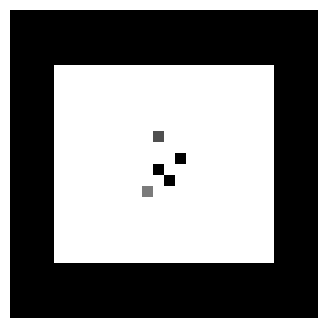

Predicted: 0  (confidence: 99.79%)
Top 5: [('0', 0.9979091286659241), ('8', 0.0005200360901653767), ('P', 0.0003223831590730697), ('C', 0.00016259105177596211), ('D', 0.00013380956079345196)]


In [18]:
sys.path.insert(0, '../src')
from predict import preprocess_image, predict_character

sample_path = "../prediction/sample_char.png"

try:
    canvas = preprocess_image(sample_path)
    plt.figure(figsize=(4, 4)); plt.imshow(canvas, cmap='gray'); plt.axis('off'); plt.show()

    predicted_char, confidence, top5 = predict_character(canvas, model, CLASS_MAPPING)
    print(f"Predicted: {predicted_char}  (confidence: {confidence*100:.2f}%)")
    print("Top 5:", top5)
except FileNotFoundError:
    print(f"Add a sample image at {sample_path} to test this cell.")